# Plotting the probability that neurons are activeduring locomotor-state transitions

by Debora Masini, 2024

This script links behavior (IMU movement state) to neuronal activity episodes extracted from calcium imaging, and produces two complementary analyses:
1. Peri-transition, time-resolved activation probability around behavior state switches
2. Per-neuron, state-dependent activation probability during sustained movement vs sustained stillness

A key prerequisite is the sign matrix, which encodes when each neuron is in an “active episode” (±1) versus inactive (0). The pipeline assumes Day 1 only.

In [3]:
import os
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

### Step 1) Peri-transition analysis of L6b activation probability
In this step, calcium activity is aligned to behavioral state transitions derived from IMU data and analyzed in a peri-event framework.

1. **Behavioral preprocessing**
- IMU movement states (47 Hz) are cleaned by removing short runs (<30 ms) using a run-length fill procedure to suppress spurious transitions.
- The filtered IMU movement trace is temporally aligned to calcium timestamps (10 Hz) using nearest-neighbor matching with a strict tolerance (≤50 ms).
- The result is a binary movement state vector expressed in calcium time.

2. **Transition detection** Behavioral transitions are identified in calcium time:
- Move → Still (1 → 0)
- Still → Move (0 → 1)
- A transition is accepted only if: ≥1 s of stable state precedes the transition. ≥1 s of stable state follows the transition.

3. **Reference conditions**  Two non-transition control conditions are also extracted:
- Still, remains still (2 s continuous immobility)
- Moving, remains moving (2 s continuous movement)
Windows are centered within sustained behavioral epochs.

4. **Peri-event window extraction** For each neuron: A ±1 s window (2 s total) around each valid transition or reference center is extracted. Activity is represented as the absolute value of the sign matrix (interpreted as activation probability). All valid windows are pooled across neurons and sessions (Day 1 only).

5. **Quantification**  For each condition: The mean activation probability across windows is computed. 95% confidence intervals are estimated using the normal approximation (1.96 × SEM).

#### Output
- A peri-transition plot showing mean ± 95% CI for each condition.
- An Excel file containing the time axis and corresponding mean/CI of activation probability.


In [ ]:
# step 1
directory = r"...\python_analysis_results"
imu_file = r"...\python_analysis_results\Final_IMU body movement data sets.csv"
sign_folder = os.path.join(directory, "results")

# params
FS = 10.0 # Calcium data is at 10Hz
window_sec = 1.0
window_frames = int(window_sec * FS)
ref_window_frames = 2 * window_frames  # 2 sec window for reference

MAX_ALIGN_DIFF = 0.05 # tolerance tied to Ca sampling, ≤ half a Ca frame (0.05 s)
IMU_FS = 47 # IMU Hz, sample rate does not follow stricktly the 50 Hz stated on the manual.

# Load IMU and filter
imu_df = pd.read_csv(imu_file)
imu_times = imu_df["IMU Time (s)"].to_numpy()
imu_movement = imu_df["movements"].to_numpy()

def fill_short_runs(arr, min_len):
    arr = arr.copy()
    n = len(arr)
    i = 0
    while i < n:
        val = arr[i]
        j = i
        while j < n and arr[j] == val:
            j += 1
        run_len = j - i
        if run_len < min_len and i > 0 and j < n:
            if arr[i-1] == arr[j]:
                arr[i:j] = arr[i-1]
        i = j
    return arr
min_run_frames = int(0.03 * IMU_FS) # 30ms, nise fill. see notes on script 2 of this folder.
imu_movement_filtered = fill_short_runs(imu_movement, min_run_frames)


# in the future perhaps vectorize with np.searchsorted. ?
def align_time_to_imu(ca_times, imu_times, imu_movement_filtered):
    movement_aligned = np.full(len(ca_times), np.nan)
    i = 0
    for t_idx, t in enumerate(ca_times):
        while i < len(imu_times)-1 and imu_times[i] < t:
            i += 1
        candidates = []
        if i < len(imu_times):
            candidates.append(i)
        if i > 0:
            candidates.append(i-1)
        best_idx = None
        best_diff = np.inf
        for ci in candidates:
            diff = abs(imu_times[ci] - t)
            if diff < best_diff:
                best_diff = diff
                best_idx = ci
        if best_diff <= MAX_ALIGN_DIFF:
            movement_aligned[t_idx] = imu_movement_filtered[best_idx]
    return movement_aligned

# Collect peri-event windows
peri_all_m2s = []   # Move→Still
peri_all_s2m = []   # Still→Move
ref_still = []      # Still, remains still
ref_move = []       # Moving, remains moving

neurons_m2s = set()
neurons_s2m = set()
neurons_ref_still = set()
neurons_ref_move = set()

# the file _sign_matrix.npy was generated on the script: Calcium Imaging_ for analysis of neuronal activity episodes...
files = [f for f in os.listdir(sign_folder) if f.endswith("_sign_matrix.npy") and "Day1" in f] # only for day 1
for fn in files:
    base = fn.replace("_sign_matrix.npy", "")
    sign_mat = np.load(os.path.join(sign_folder, fn))  # (frames, neurons)
    ca_csv = os.path.join(directory, base.replace("_sign_matrix", "") + ".csv")
    if not os.path.exists(ca_csv):
        continue
    df_ca = pd.read_csv(ca_csv)
    if "Time (s)" not in df_ca.columns:
        continue
    ca_times = df_ca["Time (s)"].to_numpy()
    movement_aligned = align_time_to_imu(ca_times, imu_times, imu_movement_filtered)
    movement_short = movement_aligned[:sign_mat.shape[0]]
    mov = movement_short
    neuron_names = [c for c in df_ca.columns if c != "Time (s)"]

    # Find transitions
    transitions_m2s = np.where((mov[:-1] == 1) & (mov[1:] == 0))[0] + 1
    transitions_s2m = np.where((mov[:-1] == 0) & (mov[1:] == 1))[0] + 1

    for n_idx, name in enumerate(neuron_names):
        s = sign_mat[:, n_idx]
        # Move→Still
        for t in transitions_m2s:
            if t - window_frames < 0 or t + window_frames >= len(mov):
                continue
            if not np.all(mov[t - window_frames:t] == 1):
                continue
            if not np.all(mov[t:t + window_frames] == 0):
                continue
            peri = np.abs(s[t - window_frames:t + window_frames])
            peri_all_m2s.append(peri)
            neurons_m2s.add((base, name))
        # Still→Move
        for t in transitions_s2m:
            if t - window_frames < 0 or t + window_frames >= len(mov):
                continue
            if not np.all(mov[t - window_frames:t] == 0):
                continue
            if not np.all(mov[t:t + window_frames] == 1):
                continue
            peri = np.abs(s[t - window_frames:t + window_frames])
            peri_all_s2m.append(peri)
            neurons_s2m.add((base, name))
        # Reference: still, remains still
        still_idxs = np.where(
            (np.convolve((mov == 0).astype(int), np.ones(ref_window_frames, int), 'valid') == ref_window_frames)
        )[0] + ref_window_frames // 2
        for idx in still_idxs:
            if idx - window_frames < 0 or idx + window_frames >= len(s):
                continue
            peri = np.abs(s[idx - window_frames:idx + window_frames])
            ref_still.append(peri)
            neurons_ref_still.add((base, name))
        # Reference: moving, remains moving
        move_idxs = np.where(
            (np.convolve((mov == 1).astype(int), np.ones(ref_window_frames, int), 'valid') == ref_window_frames)
        )[0] + ref_window_frames // 2
        for idx in move_idxs:
            if idx - window_frames < 0 or idx + window_frames >= len(s):
                continue
            peri = np.abs(s[idx - window_frames:idx + window_frames])
            ref_move.append(peri)
            neurons_ref_move.add((base, name))

# Convert to arrays for plotting
peri_all_m2s = np.array(peri_all_m2s)
peri_all_s2m = np.array(peri_all_s2m)
ref_still = np.array(ref_still)
ref_move = np.array(ref_move)
time_axis = np.arange(-window_frames, window_frames) / FS  # in seconds

Notes:
- Aligning IMU locomotor state onto the calcium timebase: cleaned at IMU rate (~47 Hz, as estimated in script 2, real doesn not mantain 50Hz) (imu_movement_filtered) is resampled/assigned to calcium timestamps via nearest-neighbor (align_time_to_imu), transitions are detected on the aligned (10 Hz) vector mov. In the previous IMU-BA script, transitions are detected directly on the IMU-sampled movement vector (same timebase as BA). Implication: transition timing can shift by up to ~½ calcium frame (~50 ms at 10 Hz).

In [ ]:
# step 1, Plot
plt.figure(figsize=(10, 6))

# Move→Still
if peri_all_m2s.shape[0] > 0:
    mean_m2s = peri_all_m2s.mean(axis=0)
    sem_m2s = peri_all_m2s.std(axis=0, ddof=1) / np.sqrt(peri_all_m2s.shape[0])
    ci_m2s = 1.96 * sem_m2s
    plt.plot(time_axis, mean_m2s, color='orange', label=f'move→immobile (n={len(peri_all_m2s)})')
    plt.fill_between(time_axis, mean_m2s - ci_m2s, mean_m2s + ci_m2s, color='orange', alpha=0.2)

# Still→Move
if peri_all_s2m.shape[0] > 0:
    mean_s2m = peri_all_s2m.mean(axis=0)
    sem_s2m = peri_all_s2m.std(axis=0, ddof=1) / np.sqrt(peri_all_s2m.shape[0])
    ci_s2m = 1.96 * sem_s2m
    plt.plot(time_axis, mean_s2m, color='blue', label=f'immobile→move (n={len(peri_all_s2m)})')
    plt.fill_between(time_axis, mean_s2m - ci_s2m, mean_s2m + ci_s2m, color='blue', alpha=0.2)

# Still, remains still
if ref_still.shape[0] > 0:
    mean_ref_still = ref_still.mean(axis=0)
    sem_ref_still = ref_still.std(axis=0, ddof=1) / np.sqrt(ref_still.shape[0])
    ci_ref_still = 1.96 * sem_ref_still
    plt.plot(time_axis, mean_ref_still, color='black', label=f'immobile, remains immobile (n={len(ref_still)})')
    plt.fill_between(time_axis, mean_ref_still - ci_ref_still, mean_ref_still + ci_ref_still, color='black', alpha=0.15)

# Moving, remains moving
#if ref_move.shape[0] > 0:
#     mean_ref_move = ref_move.mean(axis=0)
#     sem_ref_move = ref_move.std(axis=0, ddof=1) / np.sqrt(ref_move.shape[0])
#     ci_ref_move = 1.96 * sem_ref_move
#     plt.plot(time_axis, mean_ref_move, color='green', label=f'Moving, remains moving (n={len(ref_move)})')
#     plt.fill_between(time_axis, mean_ref_move - ci_ref_move, mean_ref_move + ci_ref_move, color='green', alpha=0.15)

plt.axvline(0, color='k', linestyle='--', label='Transition')
plt.xlabel("Time from transition (s)")
plt.ylabel("Probability neuron is active (mean ± 95% CI)")
plt.title("Peri-transition L6b activation probability\nLikelihood of neurons being active before/after behavioral transition")
plt.legend(loc='best', frameon=True)
plt.tight_layout()

plot_path = os.path.join(sign_folder, "peri_transition_activation_probability.svg")
plt.savefig(plot_path, format="svg")

plt.show()

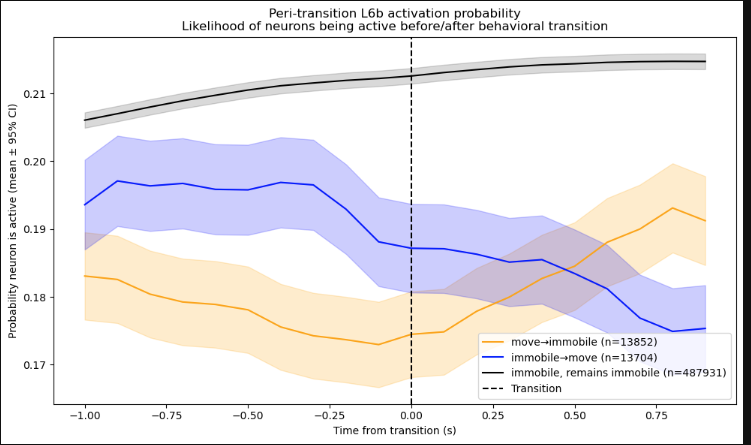


In [ ]:
# Step 1, save the raw arrays used on plot above (mean + CI)
summary_dict = {"time_s": time_axis}
if peri_all_m2s.shape[0] > 0:
    summary_dict["mean_move_to_still"] = mean_m2s
    summary_dict["ci95_move_to_still"] = ci_m2s
if peri_all_s2m.shape[0] > 0:
    summary_dict["mean_still_to_move"] = mean_s2m
    summary_dict["ci95_still_to_move"] = ci_s2m
if ref_still.shape[0] > 0:
    summary_dict["mean_still_reference"] = mean_ref_still
    summary_dict["ci95_still_reference"] = ci_ref_still

df_summary = pd.DataFrame(summary_dict)
xlsx_path = os.path.join(sign_folder, "peri_transition_activation_probability.xlsx")
df_summary.to_excel(xlsx_path, index=False)

### Step2) This step computes state-dependent activation probability per neuron, collapsed across time (no peri-event structure).
It is a global state-dependent activity probability metric of day 1. For each neuron in each file, computes the probability of being active (|sign|==1) during movement and stillness. Reports the mean and SEM of these probabilities across neurons (per file) and then across files (group level).

In [ ]:
# step 2, per neuron checks
all_rows = []

files = [f for f in os.listdir(sign_folder) if f.endswith("_sign_matrix.npy") and "Day1" in f]
for fn in files:
    base = fn.replace("_sign_matrix.npy", "")
    sign_mat = np.load(os.path.join(sign_folder, fn))  # (frames, neurons)
    ca_csv = os.path.join(directory, base.replace("_sign_matrix", "") + ".csv")
    if not os.path.exists(ca_csv):
        continue
    df_ca = pd.read_csv(ca_csv)
    if "Time (s)" not in df_ca.columns:
        continue
    ca_times = df_ca["Time (s)"].to_numpy()
    
    # Use filtered IMU movement here!
    """
    For each calcium timestamp t: Find the nearest IMU timestamp. Compute absolute time difference.
    If difference ≤ MAX_ALIGN_DIFF, assign that IMU movement state.
    Otherwise assign NaN.
    """
    movement_aligned = align_time_to_imu(ca_times, imu_times, imu_movement_filtered)
    movement_short = movement_aligned[:sign_mat.shape[0]]
    is_moving = movement_short == 1
    is_still = movement_short == 0
    neuron_names = [c for c in df_ca.columns if c != "Time (s)"]
    for i, name in enumerate(neuron_names):
        s = sign_mat[:, i]
        # Probability active during movement
        p_mov = np.mean(np.abs(s[is_moving]) == 1) if np.any(is_moving) else np.nan
        # Probability active during stillness
        p_still = np.mean(np.abs(s[is_still]) == 1) if np.any(is_still) else np.nan
        all_rows.append({
            "File": base,
            "Neuron": name,
            "ProbActive_Movement": p_mov,
            "ProbActive_Stillness": p_still
        })

df_neuron = pd.DataFrame(all_rows)
df_neuron.to_csv(os.path.join(sign_folder, "per_neuron_activation_probability_per_file.csv"), index=False)


# Melt for seaborn
df_long = df_neuron.melt(
    id_vars=["File", "Neuron"],
    value_vars=["ProbActive_Movement", "ProbActive_Stillness"],
    var_name="State",
    value_name="ActivationProbability"
)
df_long["State"] = df_long["State"].map({
    "ProbActive_Movement": "Movement",
    "ProbActive_Stillness": "Stillness"
})

plt.figure(figsize=(7, 5))
sns.stripplot(data=df_long, x="State", y="ActivationProbability", hue="File", dodge=True, alpha=0.6, jitter=0.2)

for i, state in enumerate(["Movement", "Stillness"]):
    vals = df_long[df_long["State"] == state]["ActivationProbability"].dropna()
    mean = np.mean(vals)
    sem = np.std(vals, ddof=1) / np.sqrt(len(vals))
    plt.errorbar(i, mean, yerr=sem, fmt='o', color='black', capsize=5, markersize=8, label=None, zorder=10)

plt.ylabel("Probability neuron is active (|sign|==1)")
plt.title("Per-neuron activation probability\nMovement vs Stillness")
plt.legend(title="File", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

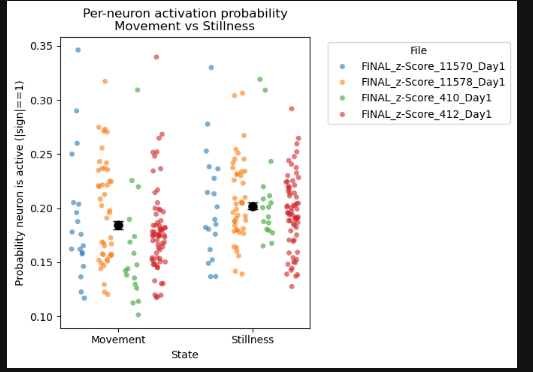


In [ ]:
# step 2) Compute stats
mean_mov = df_neuron["ProbActive_Movement"].mean()
sem_mov = df_neuron["ProbActive_Movement"].std(ddof=1) / np.sqrt(len(df_neuron))
mean_still = df_neuron["ProbActive_Stillness"].mean()
sem_still = df_neuron["ProbActive_Stillness"].std(ddof=1) / np.sqrt(len(df_neuron))

print("=== PER-NEURON PROBABILITY OF BEING ACTIVE (|sign|==1) ===")
print(f"Movement:   mean={mean_mov:.3f}, SEM={sem_mov:.3f}")
print(f"Stillness:  mean={mean_still:.3f}, SEM={sem_still:.3f}")

# Paired t-test
from scipy.stats import ttest_rel
t_stat, p_val = ttest_rel(df_neuron["ProbActive_Movement"], df_neuron["ProbActive_Stillness"])
print(f"\nPaired t-test: t={t_stat:.3f}, p={p_val:.4f}")

if p_val < 0.05:
    if mean_mov > mean_still:
        print("Conclusion: Neurons are significantly more active during MOVEMENT.")
    else:
        print("Conclusion: Neurons are significantly more active during STILLNESS.")
else:
    print("Conclusion: No significant difference in activation probability between movement and stillness.")

# Effect size (Cohen's d for paired samples)
diff = df_neuron["ProbActive_Movement"] - df_neuron["ProbActive_Stillness"]
cohens_d = diff.mean() / diff.std(ddof=1)

print(f"Effect size (Cohen's d): d={cohens_d:.3f}")

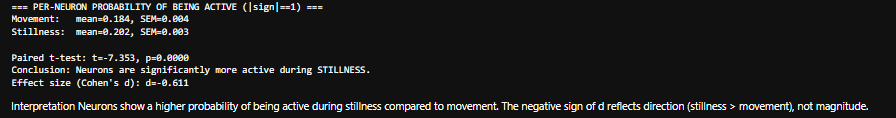
